# Markerless vs. Mocap: Project Walkthrough

**Can a two-camera markerless setup (Meta's SAM 3D Body) substitute for a marker-based Vicon mocap lab in clinical gait/movement analysis?**

This notebook is the single narrative reference for the whole seminar project. It doesn't reimplement anything — every cell below imports and calls the *actual* functions from `src/`, and loads the *actual* saved outputs in `output/`. If you want to understand how a number or a plot was produced, this notebook shows you exactly which script and which function did it, and lets you re-run the real logic on real data, right here.

The story has eight phases, plus a running regression check (`audit_all.py`). Three of those phases involved finding and fixing a real bug during development — those are told as they actually happened: a suspicious result, a mathematical invariant that proved something was wrong, a fix, and a before/after comparison on real data. You'll re-run those exact checks below.

**Dataset**: 10 movement trials (walking x3, running x2, squats x2, dance, feet-movements, random), each recorded simultaneously by a 10-camera Vicon mocap rig *and* two ordinary RGB cameras from different angles. The raw mocap/video files aren't in this repo (real human-subject research data, repo is public) — this notebook assumes you have them locally, laid out as `manifest.json` describes. Everything else (every intermediate `.npz`, every metric, every figure) is already checked into `output/` and loads directly.


## Setup

Everything below assumes you're running this notebook from `analysis/notebooks/` with the project's `.venv` as the kernel (in VS Code: select the `.venv` interpreter for this notebook). We add `../src` to the path so we can import the real project modules directly.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

ANALYSIS_DIR = Path("..").resolve()
sys.path.insert(0, str(ANALYSIS_DIR / "src"))

MANIFEST_PATH = ANALYSIS_DIR / "manifest.json"
OUTPUT_DIR = ANALYSIS_DIR / "output"

manifest = json.loads(MANIFEST_PATH.read_text())
print(f"Analysis dir: {ANALYSIS_DIR}")
print(f"Trials in manifest: {list(manifest['trials'].keys())}")


Analysis dir: D:\Kushal 2020\FAU MTech\SEMESTER 4\seminar-rma\analysis
Trials in manifest: ['dance_move_1', 'feet_movements_1', 'random_1', 'running_1', 'running_2', 'squats_1', 'squats_2', 'static', 'walking_1', 'walking_2', 'walking_3']


## Phase 0 — Environment & manifest

`src/build_manifest.py` scans the raw data folders and builds `manifest.json`: for every trial, the mocap file paths, both camera video paths (confirmed fps via ffprobe), and a `paired` flag (`static` — a standing-calibration trial — has mocap only, no video, so it's unpaired). Every later phase reads this manifest rather than re-scanning folders.

Two folder-naming quirks worth knowing if you ever touch this script: the two video folders are named `Segmented Videos _1` (space before `_1`) and `Segmented Videos_2` (no space) — inconsistent, but the manifest captures the exact real paths so nothing downstream needs to know about it.


In [2]:
paired_trials = [t for t, e in manifest["trials"].items() if e["paired"]]
print(f"{len(manifest['trials'])} total trials, {len(paired_trials)} paired (have both camera views)\n")

for trial, entry in list(manifest["trials"].items())[:3]:
    v = entry.get("views", {})
    print(f"{trial:20s} paired={entry['paired']!s:5}  "
          f"view1_fps={v.get('view1', {}).get('fps')}  view2_fps={v.get('view2', {}).get('fps')}")


11 total trials, 10 paired (have both camera views)

dance_move_1         paired=True   view1_fps=30.0  view2_fps=30.0
feet_movements_1     paired=True   view1_fps=30.0  view2_fps=30.0
random_1             paired=True   view1_fps=30.0  view2_fps=30.0


## Phase 1 — Ground truth from mocap

`src/parse_mocap.py` orchestrates the `src/mocap/` package:
- `trc_io.py` parses the 39-marker Vicon `.trc` files (100Hz, Y-up, mm).
- `joints.py` derives a **canonical 19-joint set** (`pelvis, neck, head, hip/knee/ankle/heel/toe/shoulder/elbow/wrist` x left/right) — the same joint set SAM 3D Body's output gets mapped to later, so both sides of every later comparison are directly comparable. Hip joint centers specifically use the **Davis et al. (1991) regression**, cross-checked against the exact formula embedded in this subject's own `SAM3D.vsk` anthropometry file.
- `angles.py` computes simplified sagittal-plane hip/knee/ankle flexion angles, then `parse_mocap.py` calibrates every angle against the `static` trial (so 0° means "this subject's own relaxed stance").

**Bugs found and fixed here**, in order: (1) subtracting the static calibration offset happened *after* wrapping to a fixed range, so a large offset could push values back out of range; (2) a handful of frames had heel/toe markers collapse to ~0.1mm apart (a tracking glitch), which made `atan2` blow up — fixed with a "segment too short -> NaN" guard; (3) after trying `np.unwrap` twice (made things catastrophically worse — false 360° crossings from marker noise compound permanently), the final approach wraps each trial's own angle signal around *its own circular mean*, so the branch cut lands wherever that trial's data is sparsest. This cleanly fixed 5 of 6 angle series — `ankle_flexion_right` still has a genuine, accepted residual discontinuity in dynamic trials, flagged per-trial rather than silently trusted (see the `unreliable_angles` field below).


squats_1: 2048 frames @ 100Hz, up_axis=[0. 1. 0.]
Canonical joints saved: ['pelvis', 'neck', 'head', 'hip_left', 'hip_right', 'knee_left', 'knee_right', 'ankle_left', 'ankle_right', 'heel_left', 'heel_right', 'toe_left', 'toe_right', 'shoulder_left', 'shoulder_right', 'elbow_left', 'elbow_right', 'wrist_left', 'wrist_right']
Angles flagged unreliable for this trial: [np.str_('ankle_flexion_right')]


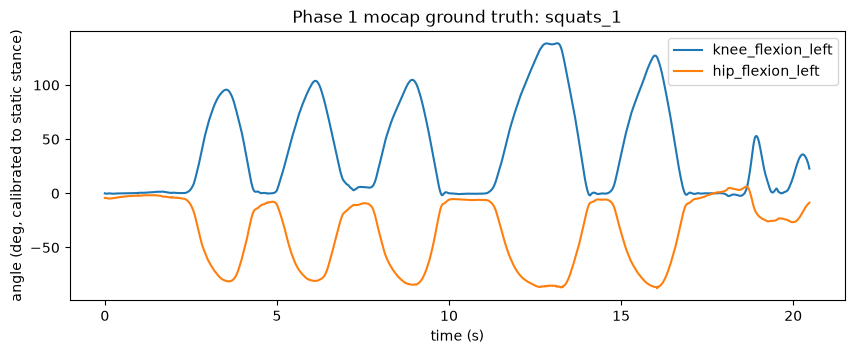

In [3]:
from joint_mapping import CANONICAL_JOINTS

trial = "squats_1"
d = np.load(OUTPUT_DIR / "mocap" / f"{trial}.npz")
print(f"{trial}: {len(d['time'])} frames @ 100Hz, up_axis={d['up_axis']}")
print(f"Canonical joints saved: {[j for j in CANONICAL_JOINTS if f'joint__{j}' in d.files]}")
print(f"Angles flagged unreliable for this trial: {list(d['unreliable_angles'])}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(d["time"], d["angle__knee_flexion_left"], label="knee_flexion_left")
ax.plot(d["time"], d["angle__hip_flexion_left"], label="hip_flexion_left")
ax.set_xlabel("time (s)")
ax.set_ylabel("angle (deg, calibrated to static stance)")
ax.set_title(f"Phase 1 mocap ground truth: {trial}")
ax.legend()
plt.show()


## Phase 2 — Per-view SAM 3D Body reconstruction

`src/run_sam3d.py` runs Meta's SAM 3D Body (a single-image full-body 3D mesh recovery model) independently on each camera view, every 3rd frame (~10fps effective — full-rate would take ~21 hours across all 20 trial/views vs. ~7 at this subsampling; fp16 doesn't work, the MHR module has a sparse op unimplemented for `Half`). It's interactive: run it and it prompts for which trial/view to process next.

**No object detector is used** — `human_detector=None`, so `process_one_image()` falls back to the full image as the bounding box. This is deliberate: it's correct for this dataset (single person, fills the frame, static camera) and avoids a Detectron2 dependency that won't build on Windows without MSVC tools.

**The most important saved field is `pred_cam_t`.** `pred_keypoints_3d` is root-relative — the model's own "pelvis" barely moves even during a full squat. The model's actual estimate of *global* translation lives separately in `pred_cam_t`, which must be added back to every joint or whole-body motion is silently lost (this exact omission was Phase 3's biggest bug — see below). `joint_mapping.sam3d_canonical_joints()` does this correctly; don't reconstruct joints from `pred_keypoints_3d` alone.


squats_1/view1: 167 frames, fields=['frame_idx', 'pred_joint_coords', 'pred_joint_coords_smoothed', 'pred_keypoints_3d', 'pred_keypoints_3d_smoothed', 'pred_keypoints_2d', 'global_rot', 'pred_cam_t', 'focal_length', 'bbox', 'frame_step']
pred_keypoints_3d shape (frames, 70 MHR joints, xyz): (167, 70, 3)

Pelvis vertical variance, root-relative only:  0.000001  (looks static!)
Pelvis vertical variance, with pred_cam_t added: 0.042339  (the real squat motion)


D:\Kushal 2020\FAU MTech\SEMESTER 4\seminar-rma\analysis\third_party\sam-3d-body\sam_3d_body\models\heads\mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


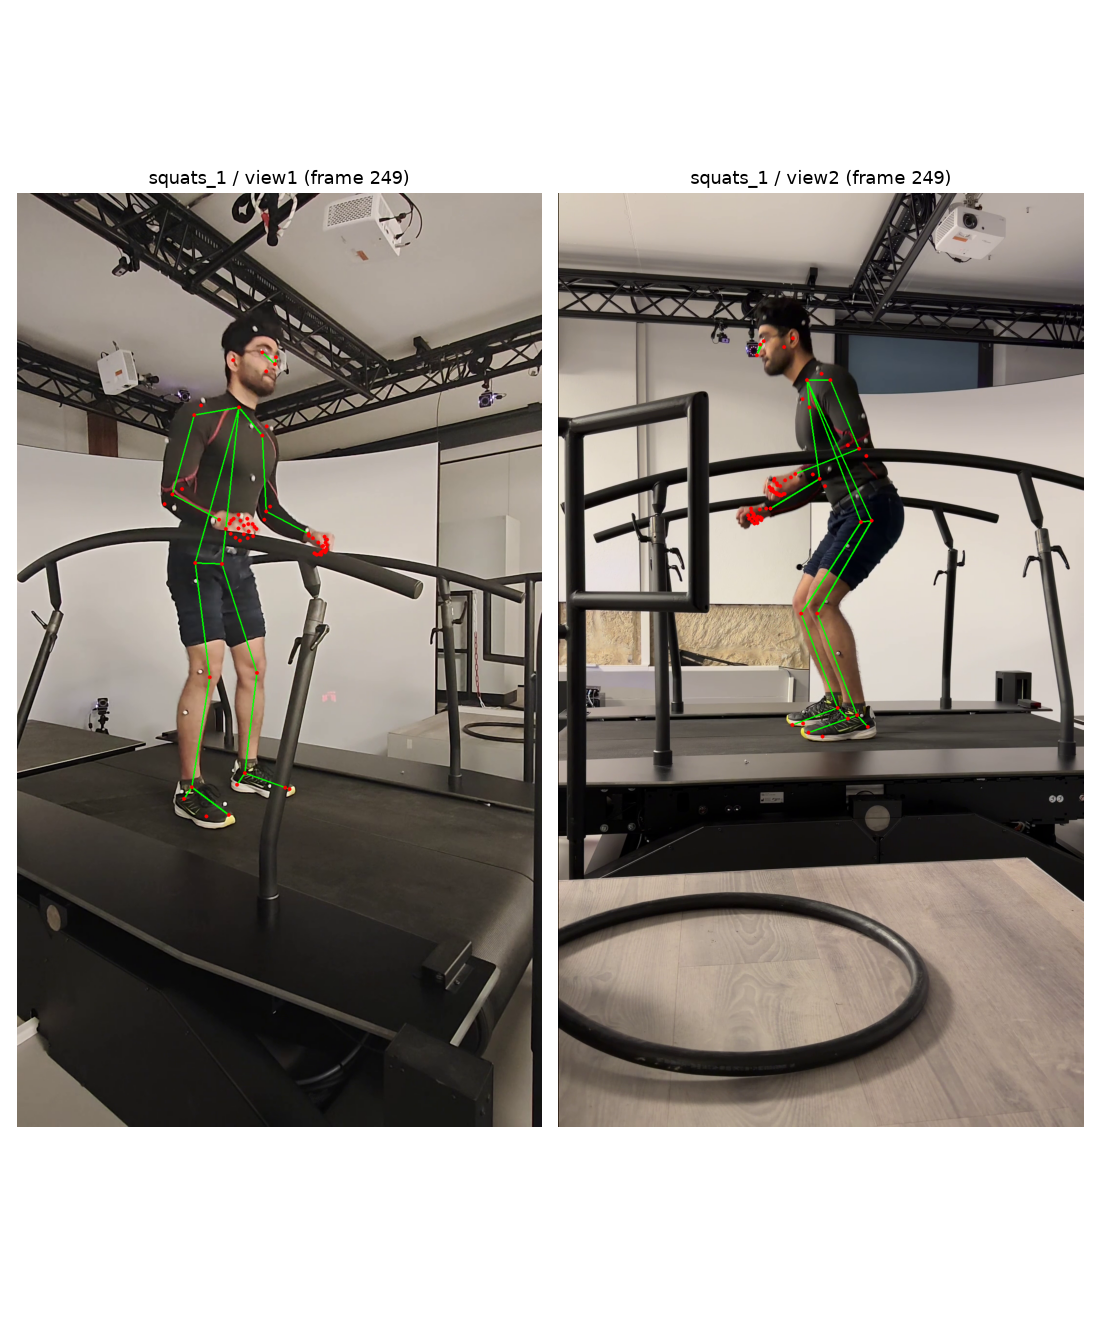

In [4]:
from joint_mapping import sam3d_canonical_joints

sys.path.insert(0, str(ANALYSIS_DIR / "third_party" / "sam-3d-body"))
from sam_3d_body.metadata.mhr70 import mhr_names  # noqa: E402

d2 = np.load(OUTPUT_DIR / "sam3d" / f"{trial}__view1.npz")
print(f"{trial}/view1: {len(d2['frame_idx'])} frames, fields={d2.files}")
print(f"pred_keypoints_3d shape (frames, 70 MHR joints, xyz): {d2['pred_keypoints_3d'].shape}")

# The real Phase 2 -> canonical-joint mapping, called exactly as Phase 3/5 call it --
# note pred_cam_t being added back in, not just pred_keypoints_3d alone.
canonical = sam3d_canonical_joints(d2["pred_keypoints_3d_smoothed"], mhr_names, d2["pred_cam_t"])
pelvis_variance_root_relative = np.var(d2["pred_keypoints_3d_smoothed"][:, mhr_names.index("left-hip"), 1])
pelvis_variance_global = np.var(canonical["pelvis"][:, 1])
print(f"\nPelvis vertical variance, root-relative only:  {pelvis_variance_root_relative:.6f}  (looks static!)")
print(f"Pelvis vertical variance, with pred_cam_t added: {pelvis_variance_global:.6f}  (the real squat motion)")

# The actual Phase 2 checkpoint figure (2D keypoints drawn on the real video frame, both views)
display(Image(filename=str(OUTPUT_DIR / "overview" / f"02_skeleton_overlay_{trial}.png")))


## Phase 3 — Alignment (and the first real bug)

`src/align.py` provides two shared primitives used by every later phase: `cross_correlate_lag` (temporal sync between two signals, with a bounded search window + broadband-signal trick to avoid locking onto a periodic gait cycle one stride away) and `umeyama_alignment` (a similarity transform — rotation + uniform scale + translation — fit via SVD). `src/run_alignment.py` uses both to bring each SAM3D view into mocap's coordinate frame and timeline.

**The bug**: while building Phase 4's per-frame Procrustes refit, a supposedly-*tighter* fit kept coming out with *higher* error than the already-aligned data — mathematically impossible for a least-squares optimizer (identity is always a feasible candidate in its own search space, so the optimum can never be worse). The cause: `R = U @ S @ Vt` should have been `R = Vt.T @ S @ U.T` — U and V's roles were swapped in the rotation formula. It had been shipping since Phase 3 was first built; a single whole-trial fit over thousands of points partially absorbed the error (translation compensates a lot when you have that much data), which is exactly why the audit's determinant/scale/visual checks hadn't caught it — none of those actually verify the fit is *optimal*, only that it's a *valid rotation*.

Let's reproduce that exact check on real data, right now.


In [5]:
from align import umeyama_alignment  # the real, currently-fixed function

d3 = np.load(OUTPUT_DIR / "aligned" / f"{trial}__view1.npz")
src = np.stack([d3[f"aligned__{j}"] for j in CANONICAL_JOINTS], axis=1)   # (F, J, 3)
dst = np.stack([d3[f"mocap__{j}"] for j in CANONICAL_JOINTS], axis=1)

f = 0  # any single frame illustrates it
valid = ~np.isnan(src[f]).any(axis=-1) & ~np.isnan(dst[f]).any(axis=-1)
s, t_ = src[f][valid], dst[f][valid]
mu_s, mu_t = s.mean(axis=0), t_.mean(axis=0)
sc, tc = s - mu_s, t_ - mu_t
sigma = (sc.T @ tc) / len(s)
U, D, Vt = np.linalg.svd(sigma)
S = np.eye(3)
if np.linalg.det(U) * np.linalg.det(Vt) < 0:
    S[-1, -1] = -1.0
var_s = np.mean(np.sum(sc ** 2, axis=1))
scale = np.trace(np.diag(D) @ S) / var_s

R_buggy = U @ S @ Vt              # the original (buggy) formula -- for illustration only
R_fixed = Vt.T @ S @ U.T          # what align.py actually does today

def sse(R):
    fitted = scale * (R @ s.T).T + (mu_t - scale * (R @ mu_s))
    return np.sum((fitted - t_) ** 2)

print(f"SSE, identity (no fit at all): {np.sum((s - t_) ** 2):>12,.0f}")
print(f"SSE, buggy R = U @ S @ Vt:     {sse(R_buggy):>12,.0f}   <- worse than doing nothing!")
print(f"SSE, fixed R = Vt.T @ S @ U.T: {sse(R_fixed):>12,.0f}   <- what align.py uses now")

# Confirm the real, fixed function agrees:
R_real, scale_real, t_real = umeyama_alignment(s, t_)
print(f"\numeyama_alignment() from align.py gives the same fixed result: "
      f"{np.allclose(R_real, R_fixed)}")


SSE, identity (no fit at all):      251,235
SSE, buggy R = U @ S @ Vt:          285,046   <- worse than doing nothing!
SSE, fixed R = Vt.T @ S @ U.T:      227,413   <- what align.py uses now

umeyama_alignment() from align.py gives the same fixed result: True


squats_1/view1 Phase 3 fit: lag=1.35s  scale=1035.0  (expected ~1000 for the m->mm conversion)  mean_residual=93.1mm


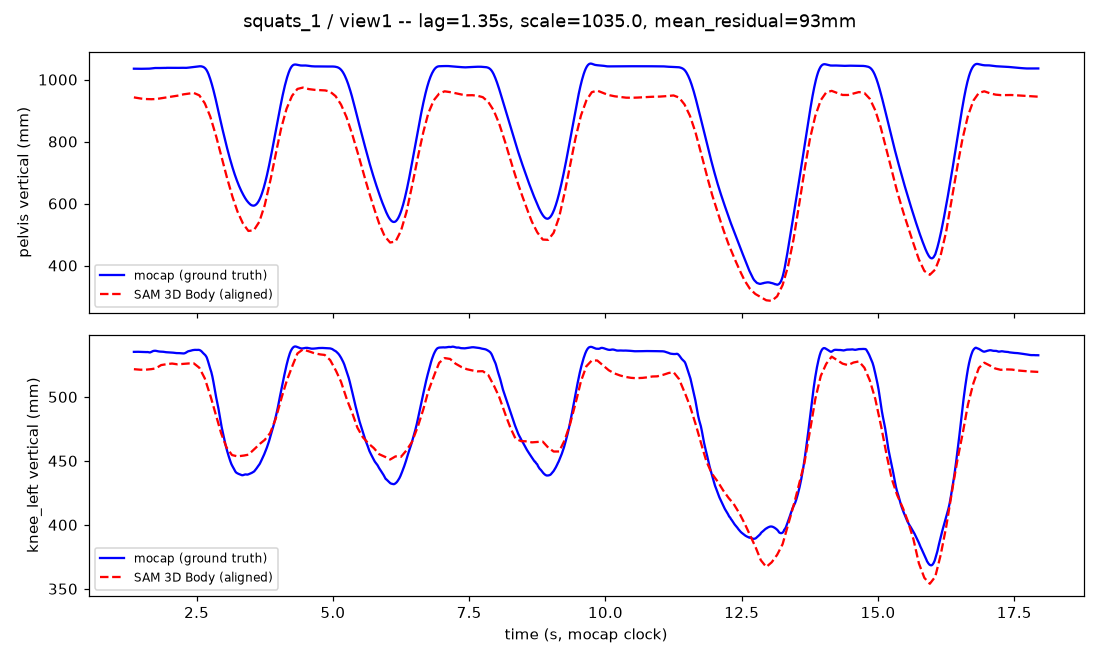

In [6]:
print(f"{trial}/view1 Phase 3 fit: lag={float(d3['lag_seconds']):.2f}s  scale={float(d3['scale']):.1f}  "
      f"(expected ~1000 for the m->mm conversion)  mean_residual={float(d3['mean_residual_mm']):.1f}mm")

# The actual Phase 3 checkpoint figure: mocap vs. aligned SAM3D trajectory, all 6 squat cycles
display(Image(filename=str(OUTPUT_DIR / "overview" / f"03_trajectory_{trial}_view1.png")))


## Phase 4 — Independent per-view metrics (and the second bug)

`src/compare_metrics.py` computes, per trial/view: **MPJPE** (mean per-joint position error using Phase 3's whole-trial fit), **PA-MPJPE** (a *fresh* per-frame Procrustes fit — this is exactly the calculation that surfaced the Phase 3 bug above), and **joint angles** (RMSE, MAE, Pearson r, Bland-Altman bias/limits of agreement). Both mocap and SAM3D angles are computed with the same joint-only method (`mocap.angles.compute_joint_angles_from_joints`), since SAM3D has no ASIS/PSIS markers for Phase 1's original marker-based pelvis frame.

**The second bug**: `hip_flexion_right` first showed a startling **r = -0.99** correlation between mocap and SAM3D — an almost perfect inversion. But `hip_flexion`'s sagittal-angle convention puts "thigh pointing straight down" (normal standing) exactly at the ±180° wrap boundary, and each side's angle is independently wrapped around *its own* circular mean (Phase 1's fix for a different problem). That means mocap and SAM3D could land on opposite sides of the same physical angle, purely as a labeling artifact of where each one's wrap point happened to fall — and Pearson correlation computed on the raw (mismatched-branch) values is meaningless when that happens. Re-expressing SAM3D's angle on mocap's own numeric branch before correlating dropped it to **r = +0.20** — a completely different, much weaker relationship, and the honest one.


In [7]:
from scipy import stats
from mocap.angles import compute_joint_angles_from_joints, wrap_around_center
from compare_metrics import MOCAP_UP, load_static_angle_offsets

mocap_j = {j: d3[f"mocap__{j}"] for j in CANONICAL_JOINTS}
sam3d_j = {j: d3[f"aligned__{j}"] for j in CANONICAL_JOINTS}
static_offsets = load_static_angle_offsets()  # the real Phase 4 calibration step

offset = static_offsets["hip_flexion_right"]
m = compute_joint_angles_from_joints(mocap_j, MOCAP_UP)["hip_flexion_right"] - offset
s = compute_joint_angles_from_joints(sam3d_j, MOCAP_UP)["hip_flexion_right"] - offset

r_raw, _ = stats.pearsonr(m, s)                       # naive: correlate the raw wrapped signals
diff = wrap_around_center(s - m, 0.0)                  # the real compare_metrics.angle_metrics() fix
s_rewrapped = m + diff
r_fixed, _ = stats.pearsonr(m, s_rewrapped)

print(f"hip_flexion_right, {trial}, view1:")
print(f"  Pearson r on raw (independently-wrapped) signals: {r_raw:+.2f}   <- looked like near-perfect inversion")
print(f"  Pearson r after re-wrapping onto mocap's branch:  {r_fixed:+.2f}   <- the real, much weaker relationship")


hip_flexion_right, squats_1, view1:
  Pearson r on raw (independently-wrapped) signals: -0.99   <- looked like near-perfect inversion
  Pearson r after re-wrapping onto mocap's branch:  +0.20   <- the real, much weaker relationship


Overall (all 20 trial/views):
  MPJPE=117.6mm  PA-MPJPE=99.7mm
  hip_flexion_left       RMSE= 17.2 deg  r=+0.14  (n=20)
  hip_flexion_right      RMSE= 55.1 deg  r=-0.53  (n=20)
  knee_flexion_left      RMSE= 35.9 deg  r=-0.02  (n=20)
  knee_flexion_right     RMSE= 83.7 deg  r=-0.34  (n=20)
  ankle_flexion_left     RMSE=155.1 deg  r=+0.57  (n=20)
  ankle_flexion_right    RMSE=153.3 deg  r=+0.81  (n=2)


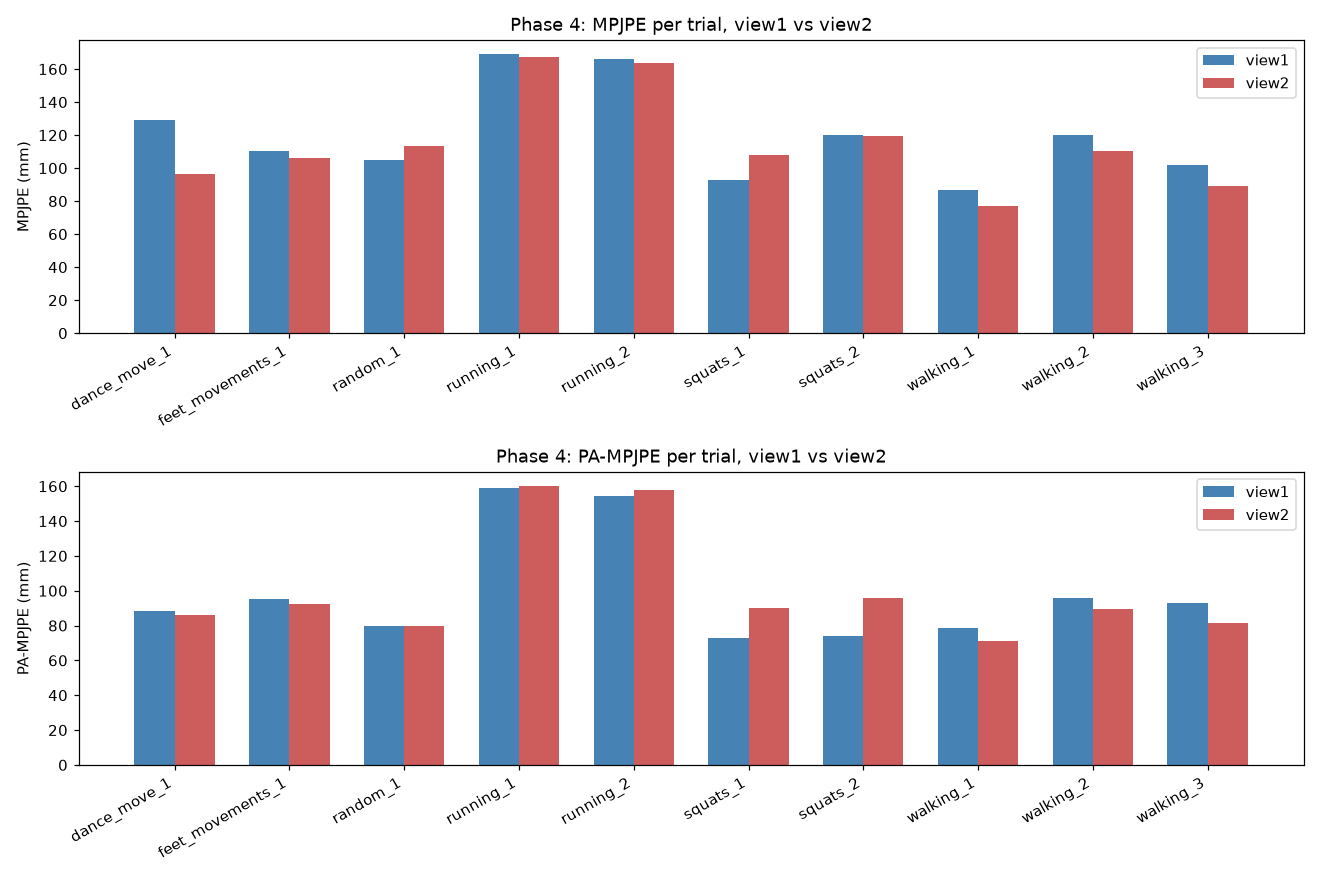

In [8]:
phase4 = json.loads((OUTPUT_DIR / "metrics" / "phase4_metrics.json").read_text())

print("Overall (all 20 trial/views):")
o = phase4["overall"]["overall"]
print(f"  MPJPE={o['mpjpe_overall_mm']:.1f}mm  PA-MPJPE={o['pa_mpjpe_mm']:.1f}mm")
for name, m in o["angles"].items():
    if m["n_trials"] > 0:
        print(f"  {name:22s} RMSE={m['rmse_deg']:5.1f} deg  r={m['pearson_r']:+.2f}  (n={m['n_trials']})")

display(Image(filename=str(OUTPUT_DIR / "overview" / "05_phase4_view_comparison.png")))


## Phase 5 — Cross-view fusion (and the third bug)

`src/fuse_views.py` fuses view1 and view2 using **only the two RGB views** — no mocap, no camera calibration (the `.xcp` calibration only covers the mocap infrared cameras). Per trial: (1) cross-correlate view1 vs. view2 directly to sync their timelines, (2) one whole-trial rigid+scale fit bringing view2 into view1's coordinate frame, (3) a **per-frame two-shape Generalized Procrustes Analysis** (`gpa_two_shapes`) on the root-centered skeletons, symmetrically rotating *both* views toward their consensus shape, (4) average the aligned root position and root-relative shape separately.

**The third bug**: `gpa_two_shapes`'s iteration never actually converged — `shift` (how much the running mean shape moves each iteration) never dropped below its own tolerance even after `max_iter=10`, with the recovered scale still visibly drifting. The cause is a classic, well-known GPA degeneracy: averaging two not-yet-aligned shapes always yields an equal-or-*smaller* size than either input, so the mean shape shrinks a little every iteration, which then pulls the next fit's scale down further — a slow collapse with no fixed point. The fix: re-anchor the mean shape's RMS size to a fixed target every iteration. That alone took convergence from "never, drifting" to ~2 iterations.


In [9]:
from fuse_views import (
    load_view_joints, vertical_component, _procrustes_rotation_scale, _rms_size, _rescale_to_rms, gpa_two_shapes,
)
from align import cross_correlate_lag, resample_joints_to_times, apply_similarity

entry = manifest["trials"][trial]
j1, t1, up1 = load_view_joints(trial, "view1", entry["views"]["view1"]["fps"])
j2, t2, up2 = load_view_joints(trial, "view2", entry["views"]["view2"]["fps"])
lag = cross_correlate_lag(t1, vertical_component(j1, up1), t2, vertical_component(j2, up2))
j2_resampled, valid_mask = resample_joints_to_times(t2 + lag, j2, t1)
j1_overlap = {n: a[valid_mask] for n, a in j1.items()}
src_pts = np.concatenate([j2_resampled[j] for j in CANONICAL_JOINTS], axis=0)
dst_pts = np.concatenate([j1_overlap[j] for j in CANONICAL_JOINTS], axis=0)
fit_mask = ~np.isnan(src_pts).any(axis=-1) & ~np.isnan(dst_pts).any(axis=-1)
R, scale2, t2_ = umeyama_alignment(src_pts[fit_mask], dst_pts[fit_mask])
j2_aligned = {n: apply_similarity(a, R, scale2, t2_) for n, a in j2_resampled.items()}

f = 0
root1, root2 = j1_overlap["pelvis"][f], j2_aligned["pelvis"][f]
x1 = np.stack([j1_overlap[j][f] - root1 for j in CANONICAL_JOINTS])
x2 = np.stack([j2_aligned[j][f] - root2 for j in CANONICAL_JOINTS])

# The original (buggy) loop -- no size re-anchoring
mean_shape = 0.5 * (x1 + x2)
print(f"{'iter':>4} {'buggy scale s1':>16} {'shift':>10}")
for it in range(10):
    R1, s1 = _procrustes_rotation_scale(x1, mean_shape)
    R2, s2 = _procrustes_rotation_scale(x2, mean_shape)
    x1a, x2a = s1 * (R1 @ x1.T).T, s2 * (R2 @ x2.T).T
    new_mean = 0.5 * (x1a + x2a)
    shift = np.mean(np.linalg.norm(new_mean - mean_shape, axis=-1))
    if it < 3 or it == 9:
        print(f"{it:>4} {s1:>16.4f} {shift:>10.6f}   <- still drifting, never below tol=1e-4")
    mean_shape = new_mean

# The real, fixed function
_, _, converged = gpa_two_shapes(x1, x2)
print(f"\nReal gpa_two_shapes() from fuse_views.py converges: {converged}")


iter   buggy scale s1      shift
   0           0.9528   0.002527   <- still drifting, never below tol=1e-4
   1           0.9488   0.002040   <- still drifting, never below tol=1e-4
   2           0.9451   0.002032   <- still drifting, never below tol=1e-4
   9           0.9193   0.001976   <- still drifting, never below tol=1e-4

Real gpa_two_shapes() from fuse_views.py converges: True


squats_1: fusion lag=-0.10s  scale(view2->view1)=0.927  n_unconverged=0  mean disagreement=0.0539 (model units)


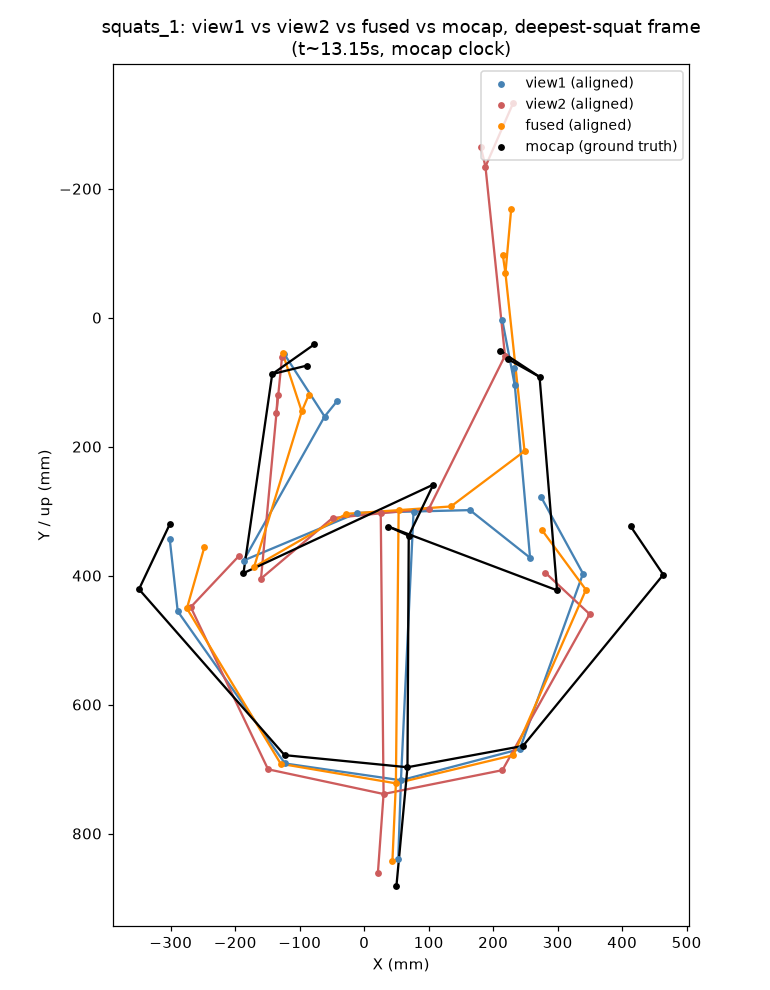

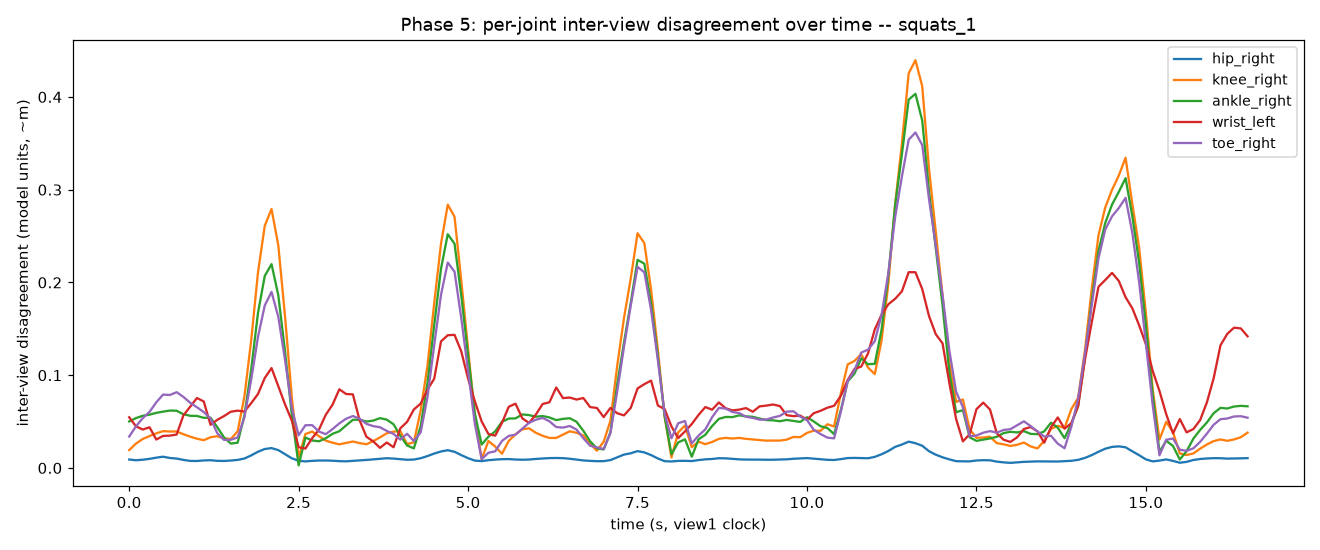

In [10]:
d5 = np.load(OUTPUT_DIR / "fused" / f"{trial}.npz")
all_disagreement = np.concatenate([d5[f"disagreement__{j}"] for j in CANONICAL_JOINTS])
print(f"{trial}: fusion lag={float(d5['lag_seconds']):.2f}s  scale(view2->view1)={float(d5['scale_view2_to_view1']):.3f}  "
      f"n_unconverged={int(d5['n_unconverged'])}  mean disagreement={np.nanmean(all_disagreement):.4f} (model units)")

# The actual Phase 5 checkpoint figures: view1/view2/fused/mocap skeleton overlay,
# and per-joint disagreement over time (spikes in sync with each squat cycle for
# distal joints; hip_right stays flat -- it's close to the root by construction)
display(Image(filename=str(OUTPUT_DIR / "overview" / f"06_phase5_skeleton_overlay_{trial}.png")))
display(Image(filename=str(OUTPUT_DIR / "overview" / f"07_phase5_disagreement_{trial}.png")))


## Phase 6 — Fused vs. mocap

`src/align_fused.py` aligns the fused trajectory to mocap using **exactly the same method Phase 3 used per view** (cross-correlation + whole-trial Umeyama fit) — this is the *only* place mocap touches the fused dataset; everything up to here was view1-vs-view2 only. `src/compare_metrics_fused.py` then computes the same MPJPE/PA-MPJPE/joint-angle metrics as Phase 4, by importing Phase 4's functions directly rather than re-implementing them (so the two are guaranteed comparable, not just similar).


squats_1: view1=93.1mm  view2=107.8mm  fused=85.1mm  (fused beats the best single view here: True)


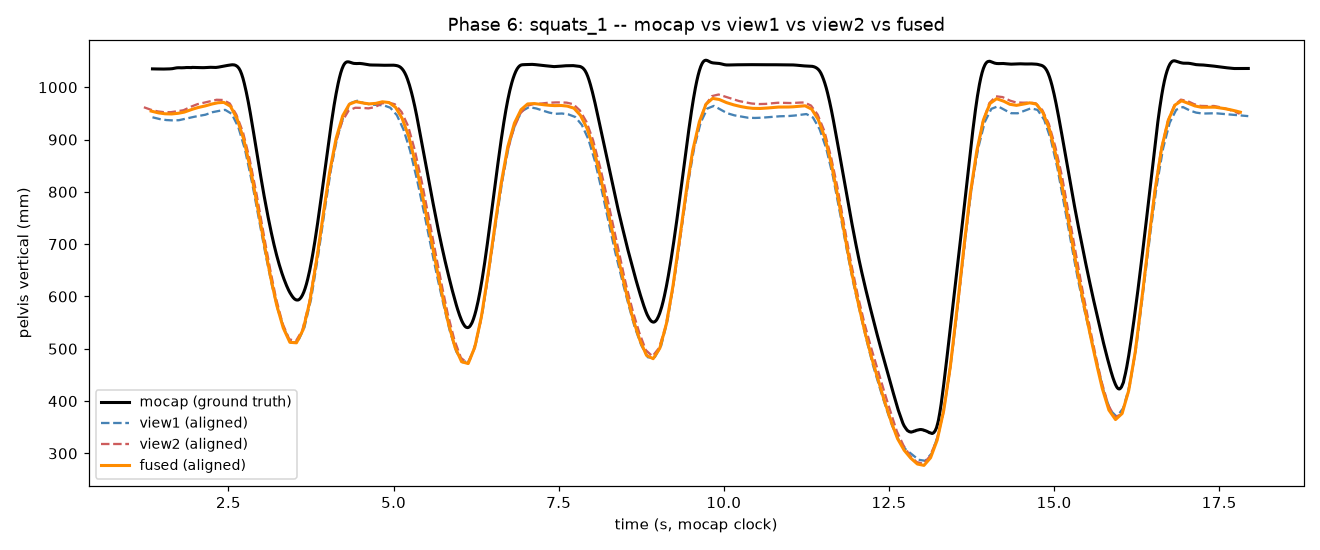

In [11]:
phase6 = json.loads((OUTPUT_DIR / "metrics" / "phase6_metrics.json").read_text())
d6 = np.load(OUTPUT_DIR / "aligned_fused" / f"{trial}.npz")

v1_mpjpe = next(r for r in phase4["per_trial_view"] if r["trial"] == trial and r["view"] == "view1")["mpjpe_overall_mm"]
v2_mpjpe = next(r for r in phase4["per_trial_view"] if r["trial"] == trial and r["view"] == "view2")["mpjpe_overall_mm"]
fused_mpjpe = next(r for r in phase6["per_trial"] if r["trial"] == trial)["mpjpe_overall_mm"]
print(f"{trial}: view1={v1_mpjpe:.1f}mm  view2={v2_mpjpe:.1f}mm  fused={fused_mpjpe:.1f}mm  "
      f"(fused beats the best single view here: {fused_mpjpe < min(v1_mpjpe, v2_mpjpe)})")

display(Image(filename=str(OUTPUT_DIR / "overview" / f"08_phase6_trajectory_{trial}.png")))


## Phase 7 — Capstone synthesis

`src/synthesize.py` reads only the already-computed Phase 4 and Phase 6 metrics (no new alignment/inference) and builds the view1-vs-view2-vs-fused comparison across every trial, joint, and action category, plus a specific empirical test: **does Phase 5's inter-view disagreement (computed with zero mocap involved) predict the fused joint's actual error against mocap?** If yes, that would justify building a confidence-weighted fusion (down-weighting joints the two cameras disagree on); if no, it wouldn't be worth building.

**The finding**: fusion beats the best single view's MPJPE in 7/10 trials (+3.7% mean), but is a wash on PA-MPJPE and does *nothing* for joint angles — it's fixing independent per-camera noise (biggest wins: shoulders, heels, wrists, ankles, all +10-17%), not the systematic `hip_right` bias (+1.0% only, since both cameras share that occlusion). The confidence-weighting premise came back essentially null (r=-0.13, p=0.07 — not even significant at the conventional 0.05 threshold) — `hip_right` has *low* disagreement (both cameras agree with each other) despite having the *highest* true error, because it's close to the GPA root-centering point by construction, not because the cameras are more confident there. **Verdict**: not clinically usable yet (MPJPE ~3.5x worse, joint angles ~3-8x worse than published thresholds), but the gap looks addressable (no calibration, no detector, simplified angle convention) rather than fundamental.


Fusion beats best single view (MPJPE): 7/10 trials
Mean MPJPE change vs best view: +3.7%
Mean PA-MPJPE change vs best view: -0.8%

Confidence-weighting premise test: r=-0.13 (p=0.07), 190 (trial, joint) pairs -- essentially null

Where does fusion help most (top 5 joints by MPJPE improvement):
  shoulder_right  +17.3%
  shoulder_left   +15.4%
  heel_left       +12.2%
  wrist_left      +11.9%
  ankle_right     +11.5%
...and least (bottom 3):
  toe_right        +4.0%
  hip_left         +2.6%
  hip_right        +1.0%


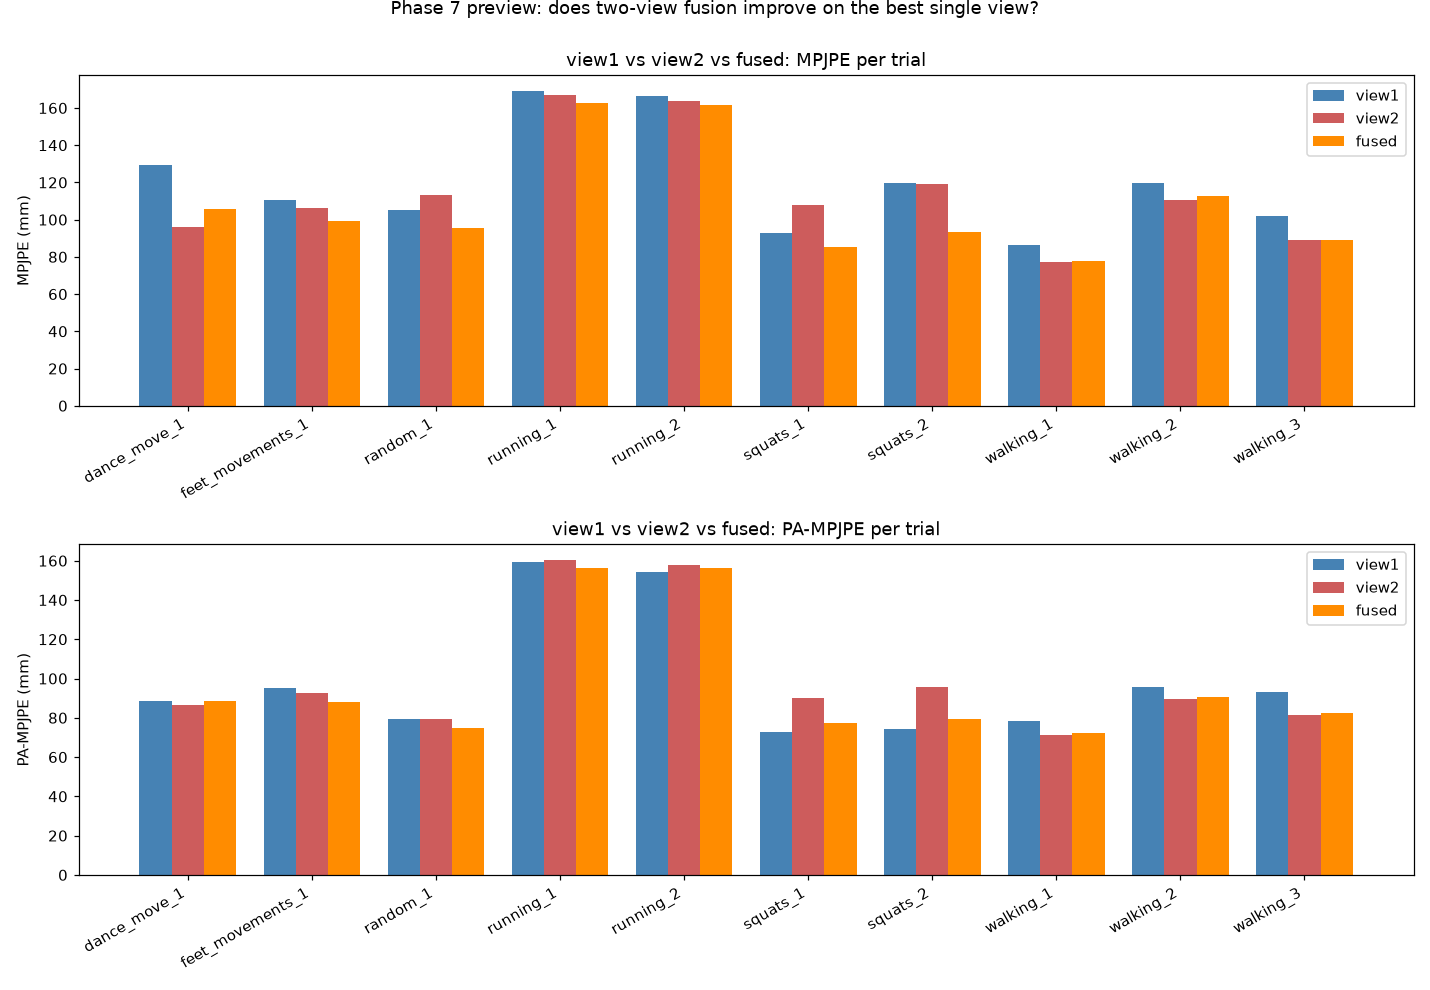

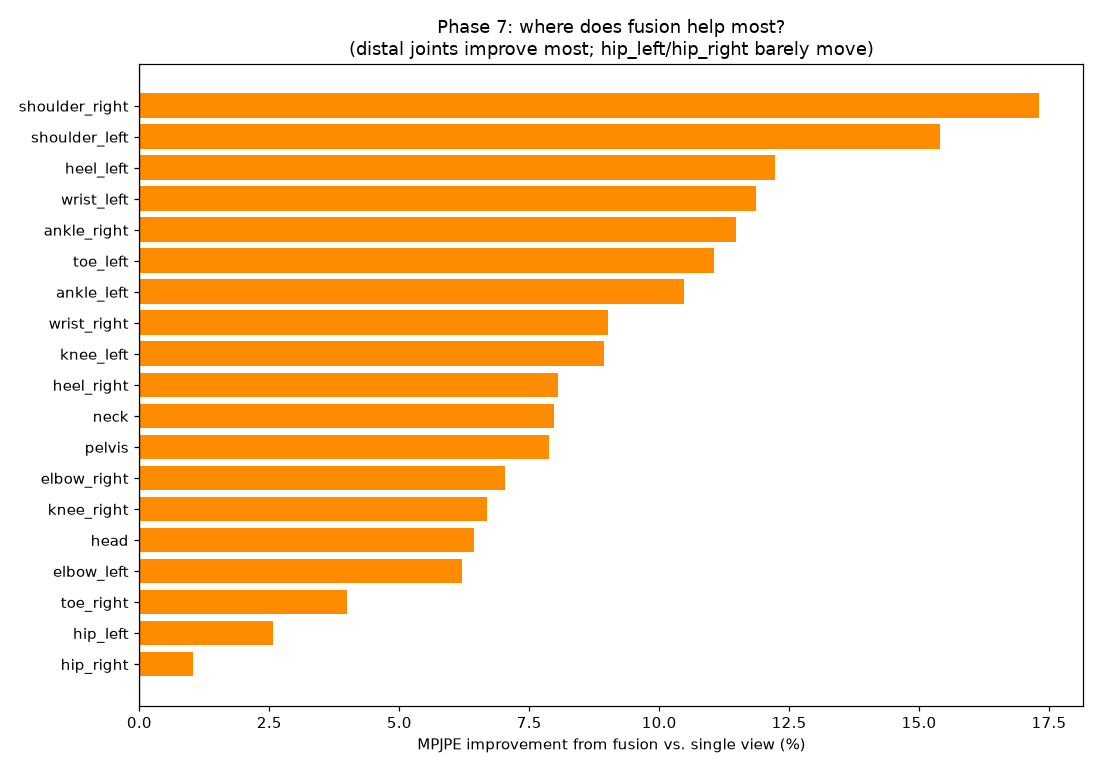

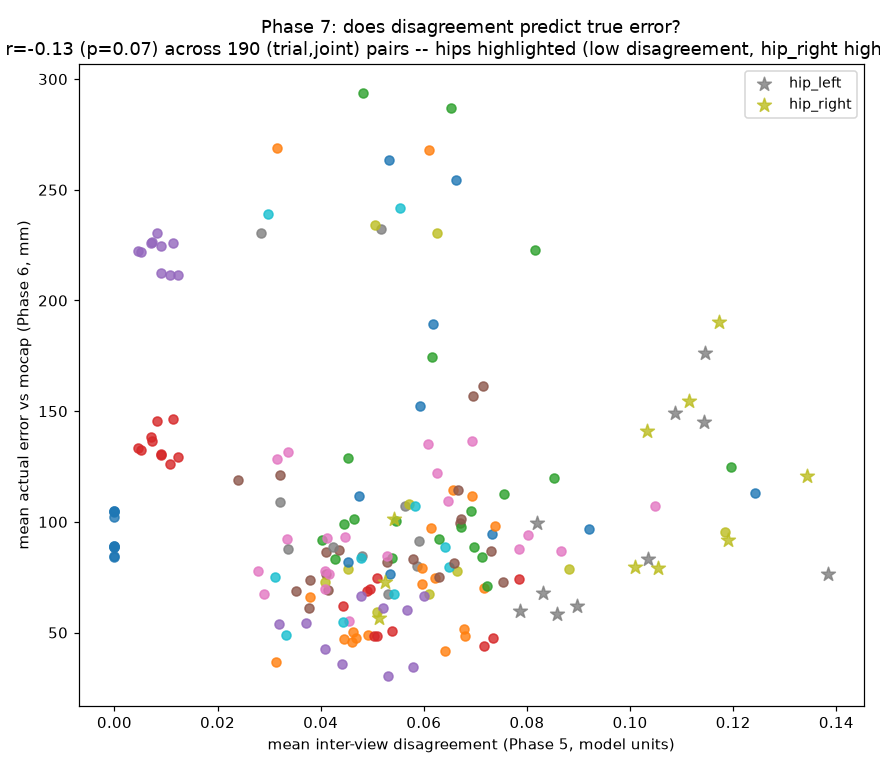

In [12]:
synthesis = json.loads((OUTPUT_DIR / "synthesis" / "phase7_synthesis.json").read_text())

h = synthesis["headline"]
print(f"Fusion beats best single view (MPJPE): {h['n_trials_fused_beats_best_view_mpjpe']}/{h['n_trials']} trials")
print(f"Mean MPJPE change vs best view: {h['mean_fused_vs_best_view_mpjpe_pct']:+.1f}%")
print(f"Mean PA-MPJPE change vs best view: {h['mean_fused_vs_best_view_pa_mpjpe_pct']:+.1f}%\n")

c = synthesis["confidence_weighting_premise_test"]
print(f"Confidence-weighting premise test: r={c['pearson_r']:+.2f} (p={c['p_value']:.2f}), "
      f"{c['n_pairs']} (trial, joint) pairs -- essentially null\n")

print("Where does fusion help most (top 5 joints by MPJPE improvement):")
for row in synthesis["per_joint"][:5]:
    print(f"  {row['joint']:15s} {row['improvement_pct']:+5.1f}%")
print("...and least (bottom 3):")
for row in synthesis["per_joint"][-3:]:
    print(f"  {row['joint']:15s} {row['improvement_pct']:+5.1f}%")

display(Image(filename=str(OUTPUT_DIR / "overview" / "09_synthesis_preview.png")))
display(Image(filename=str(OUTPUT_DIR / "overview" / "10_phase7_joint_improvement.png")))
display(Image(filename=str(OUTPUT_DIR / "overview" / "11_phase7_confidence_premise.png")))


## Phase 8 — Final visualization & reporting

`src/visualize_final.py` produces the presentation-ready figures in `output/final/`, distinct from the mid-session checkpoint plots in `output/overview/`: joint-angle time series, **pooled Bland-Altman plots** (built from real per-frame data, not just the summary bias/LoA numbers), an MPJPE summary, and a skeleton filmstrip across one full squat cycle. `report_data.json` collects every number behind every figure in one place.

Two things the checkpoint numbers alone didn't show, that only became visible in these figures: the Bland-Altman scatter isn't a random cloud — it traces smooth loops (autocorrelated time-series frames, not independent samples) and reveals that **disagreement grows substantially at extreme joint angles** (deep squat) vs. near-neutral stance. And `knee_flexion_left`'s estimated peaks run at roughly **2x mocap's amplitude** during deep flexion — visually a much stronger caveat than the ~35° RMSE number alone conveyed.


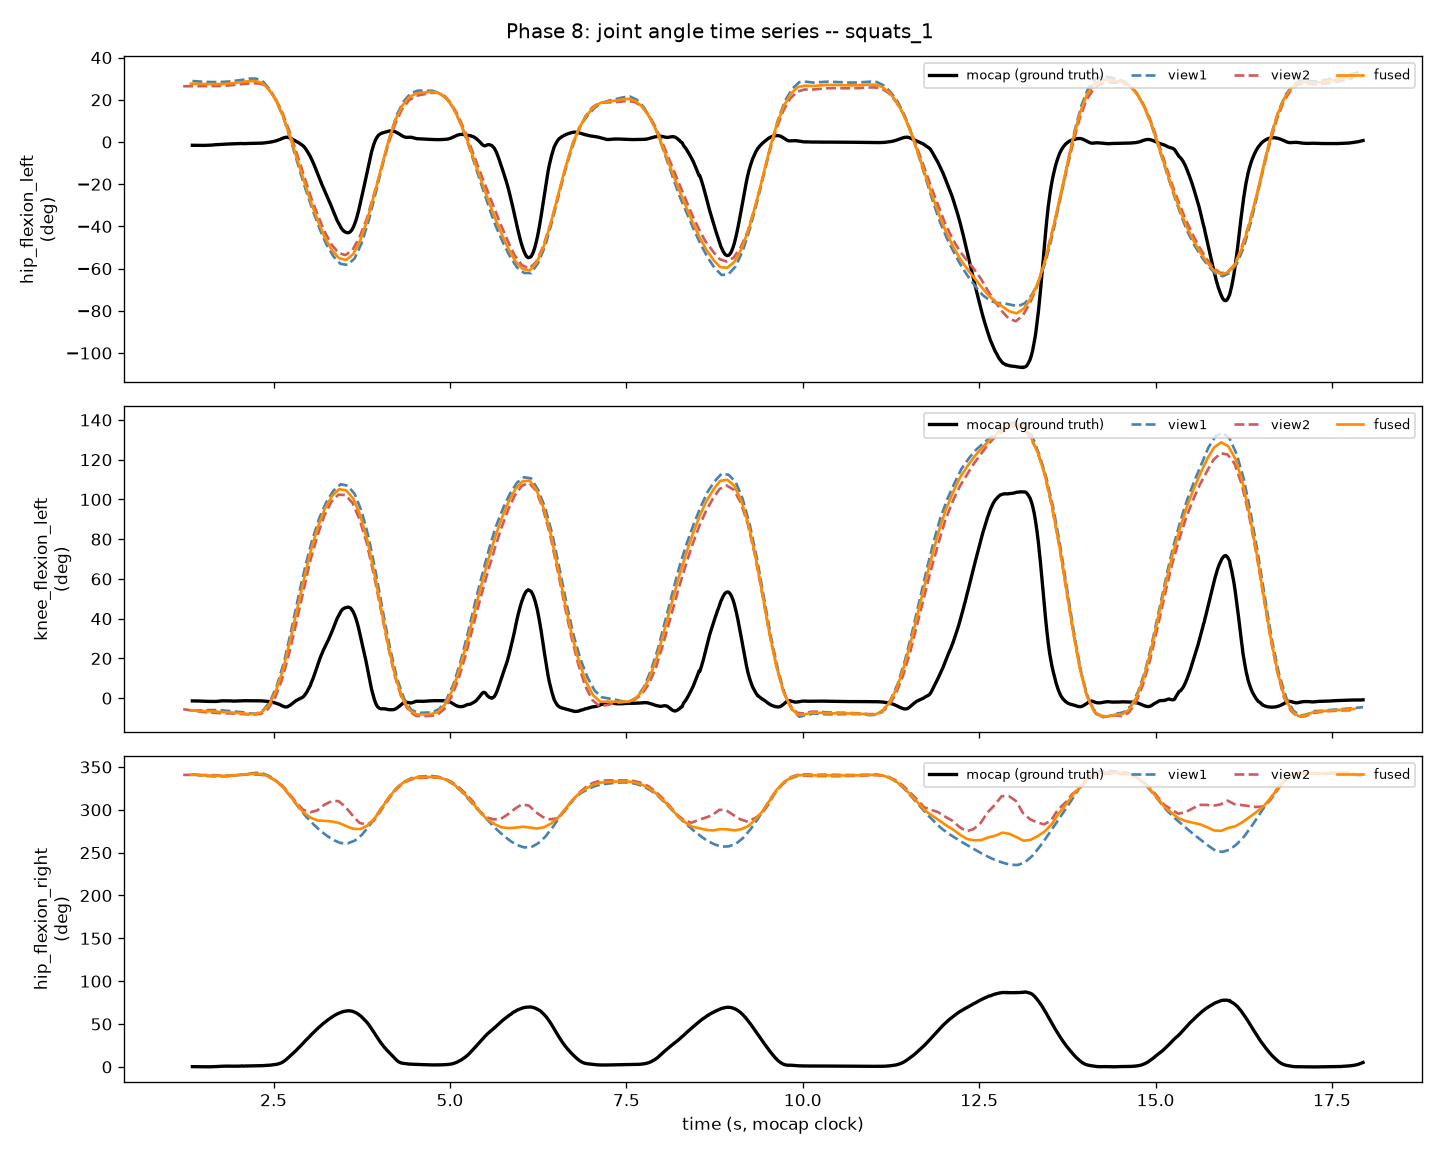

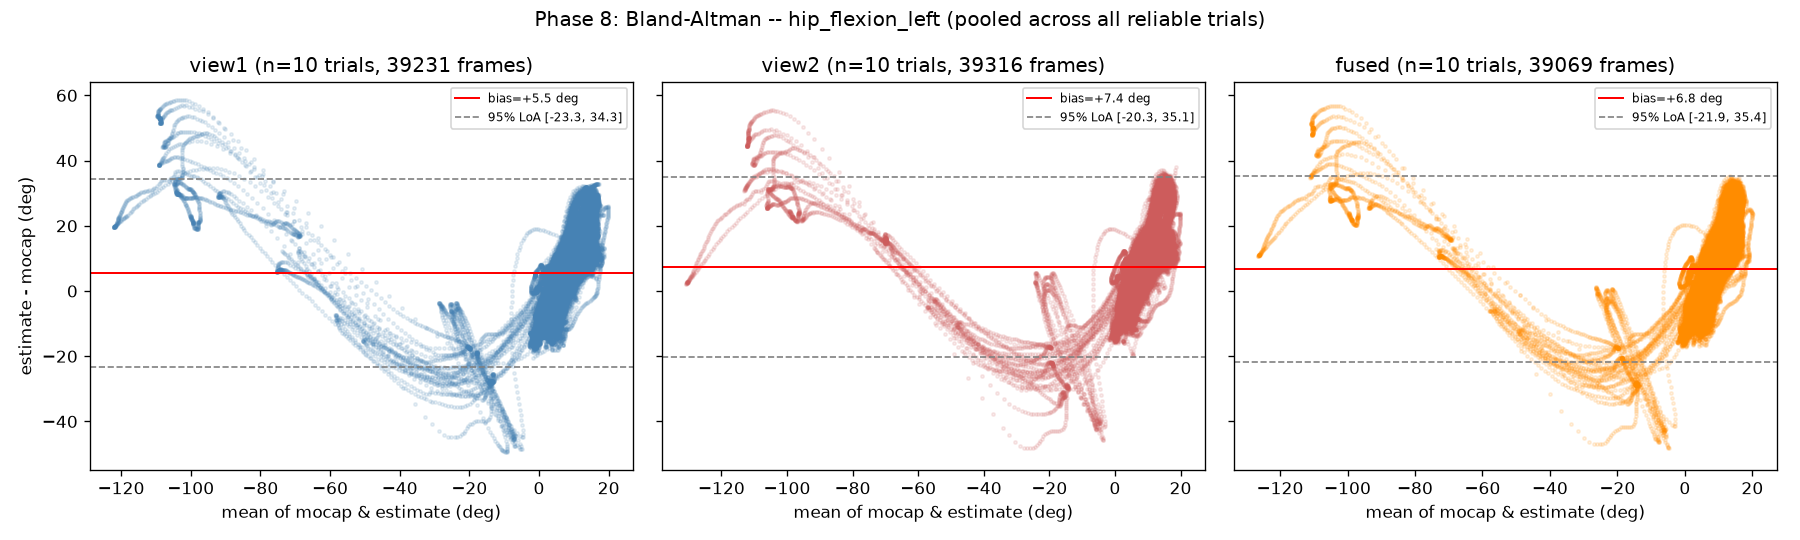

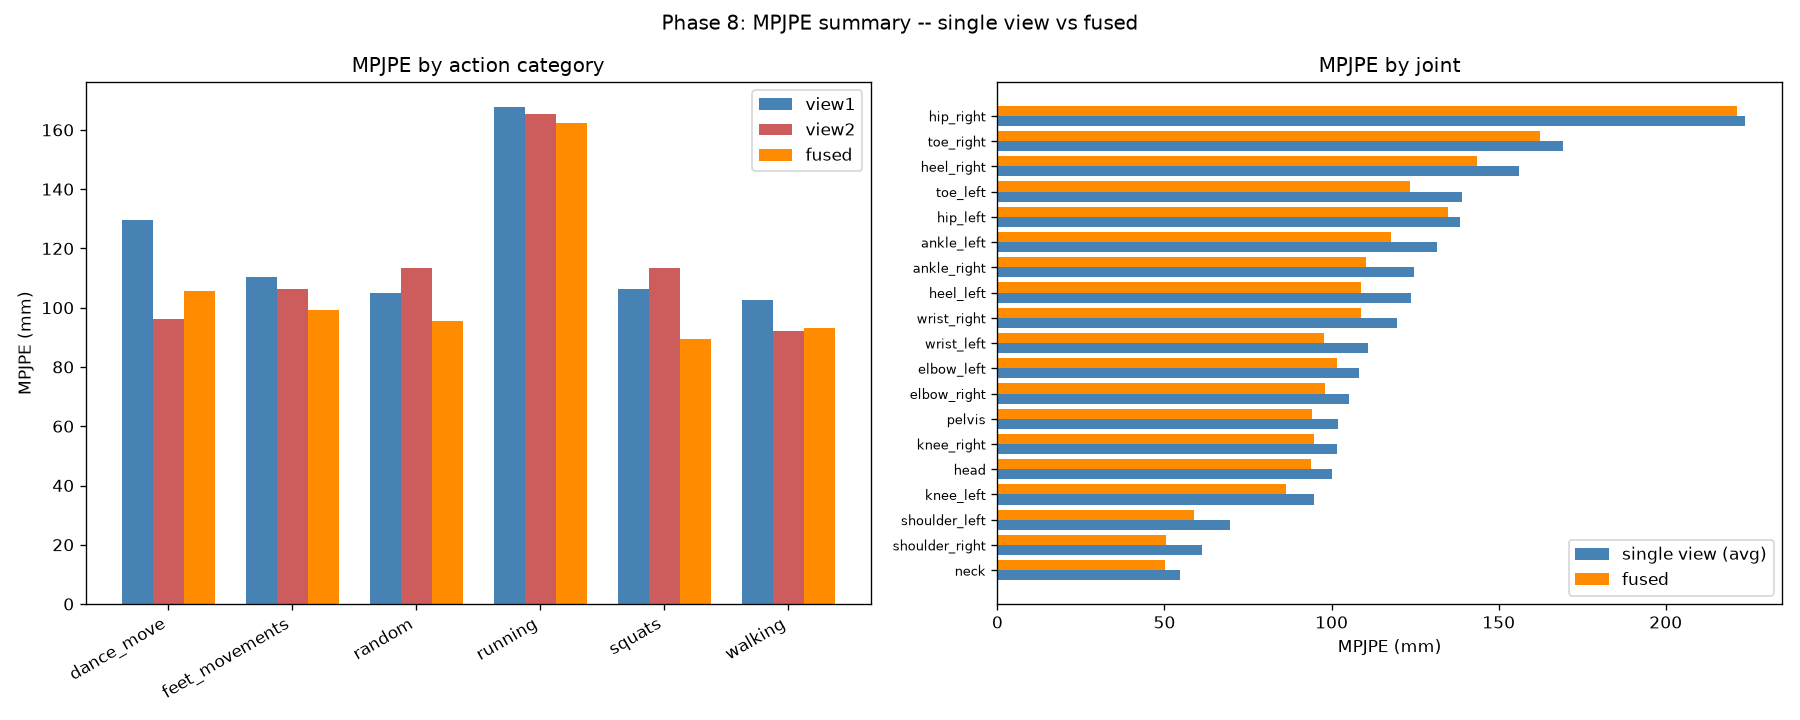

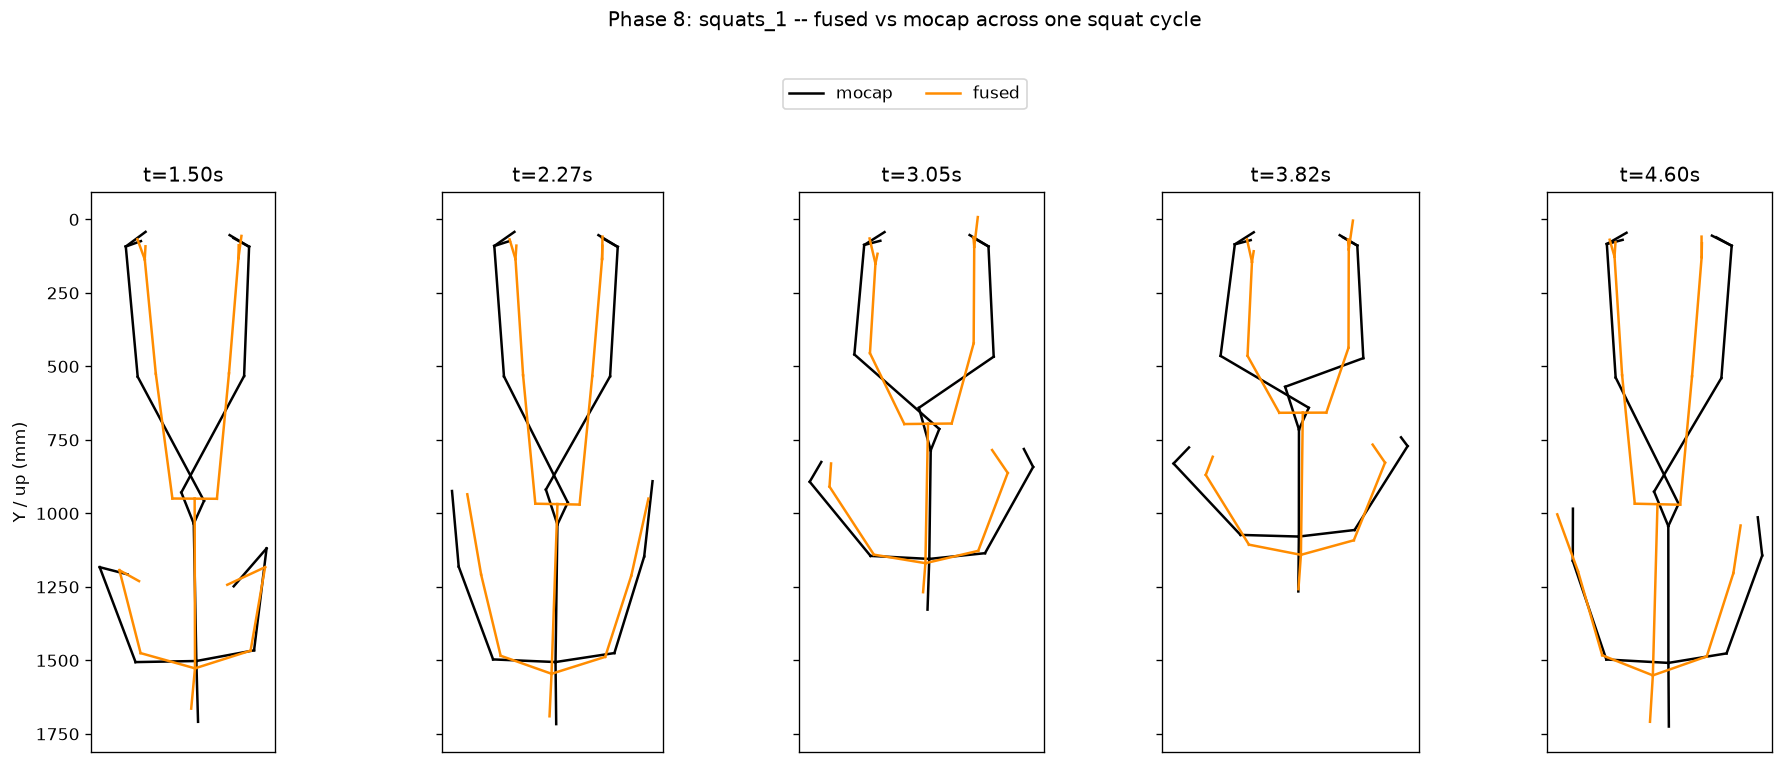

In [13]:
display(Image(filename=str(OUTPUT_DIR / "final" / f"angle_timeseries_{trial}.png")))
display(Image(filename=str(OUTPUT_DIR / "final" / "bland_altman_hip_flexion_left.png")))
display(Image(filename=str(OUTPUT_DIR / "final" / "mpjpe_summary.png")))
display(Image(filename=str(OUTPUT_DIR / "final" / f"skeleton_filmstrip_{trial}.png")))


## Postscript — a fourth bug, found by manually double-checking

After Phase 8, `src/export_trc.py` was added to export the aligned outputs as `.trc` files (same format as the raw mocap), so they can be loaded directly next to the real ground-truth `.trc` in Vicon Nexus/Visual3D/OpenSim. That raised a natural question: were the temporal alignments (Phase 3's and Phase 5's cross-correlation lags) actually correct, or just "close enough that nobody had checked"?

Manually spot-checking two flagged trials answered that with a clear no for three specific cases. Cross-correlation on long, highly periodic trials (walking, running) has a known failure mode: the single strongest correlation peak can be a "cycle-slip" — a lag that's some multiple of the gait cycle away from the true one, stronger purely by chance over a 60+ second recording. A single video frame can't disambiguate this (the pose repeats every stride, so a wrong-by-one-cycle frame looks just as plausible). The decisive check was **triangulation**: Phase 3 gives two *independent* view-to-mocap lags per trial; Phase 5's view1-vs-view2 lag should be consistent with their difference. For `walking_2`, `walking_1`, and `walking_3`, it wasn't — and directly re-fitting with the alternate candidate lag confirmed it: `walking_2`/view2's residual dropped from 241mm to 110mm using a lag the algorithm had originally rejected.

**The fix**: `align.cross_correlate_lag_candidates()` now returns the top several correlation peaks instead of just the strongest one, and every caller (Phase 3, Phase 5, Phase 6) tries each candidate against the real downstream spatial-alignment residual and keeps whichever actually fits best — not whichever correlated strongest. This is a genuine algorithmic fix, not a per-trial patch: re-running the full pipeline with it caught the three known cases *and* two more (`running_2`/view1, `walking_3`/view2) that hadn't been flagged before.


In [14]:
from align import cross_correlate_lag_candidates

# Re-derive the competing correlation peaks for walking_2/view2 -- the
# strongest one (what the old code would have picked) vs. the one the new
# residual-based selection actually chose.
d_bug4 = np.load(OUTPUT_DIR / "aligned" / "walking_2__view2.npz")
print(f"walking_2/view2 now uses lag={float(d_bug4['lag_seconds']):.2f}s, "
      f"mean_residual={float(d_bug4['mean_residual_mm']):.1f}mm")
print("(before this fix: lag=2.84s -- the strongest correlation peak -- gave mean_residual=241mm)")

# The general fix in action: view1-vs-view2 candidates for walking_1, where
# the strongest peak (-2.70s) was wrong and a much weaker peak (-0.20s) was right.
entry1 = manifest["trials"]["walking_1"]
jw1, tw1, upw1 = load_view_joints("walking_1", "view1", entry1["views"]["view1"]["fps"])
jw2, tw2, upw2 = load_view_joints("walking_1", "view2", entry1["views"]["view2"]["fps"])
candidates = cross_correlate_lag_candidates(tw1, vertical_component(jw1, upw1), tw2, vertical_component(jw2, upw2))
print("\nwalking_1 view1-vs-view2 correlation peaks (lag, relative strength):")
for lag, strength in candidates:
    print(f"  lag={lag:+.2f}s  relative_strength={strength:.3f}")
d_fused1 = np.load(OUTPUT_DIR / "fused" / "walking_1.npz")
print(f"\nActually used (by residual, not strength): lag={float(d_fused1['lag_seconds']):.2f}s")


walking_2/view2 now uses lag=2.20s, mean_residual=110.5mm
(before this fix: lag=2.84s -- the strongest correlation peak -- gave mean_residual=241mm)

walking_1 view1-vs-view2 correlation peaks (lag, relative strength):
  lag=-2.70s  relative_strength=1.000
  lag=+2.30s  relative_strength=0.910
  lag=-1.50s  relative_strength=0.878
  lag=-0.20s  relative_strength=0.797
  lag=+1.00s  relative_strength=0.775

Actually used (by residual, not strength): lag=-0.20s


## The running regression check: `audit_all.py`

Every one of the three bugs above was found *because* something downstream looked suspicious, not because a test caught it in advance. `src/audit_all.py` exists so that doesn't have to happen again: it re-checks every trial across every phase (NaN patterns, angle-range sanity, R-matrix reflection, the PA-MPJPE<=MPJPE invariant that caught bug #1, the GPA convergence flag that catches bug #3, wrap-bound/correlation-validity checks related to bug #2, and left/right labeling consistency) and prints `OK` or a specific `CHECK:` reason per trial. Run it from a terminal after touching `mocap/`, `align.py`, `joint_mapping.py`, `compare_metrics.py`, `fuse_views.py`, or `align_fused.py`:

```powershell
.venv\Scripts\python.exe src\audit_all.py
```

## Where to go from here

- **Full numbers**: `output/synthesis/phase7_synthesis.json` and `output/final/report_data.json`.
- **Reproducing from raw data**: see the README's step-by-step setup (venv, SAM 3D Body checkpoint, running each phase's script in order).
- **Next phases, if continued**: Phase 9's stretch goal (calibrated triangulation, to see how much accuracy is lost by skipping calibration) was intentionally left out of scope here.
- **Every figure in this notebook** was generated by a real script in `src/` — if a number or plot looks surprising, the fastest way to understand it is to open that script directly and read the docstring at the top; every one of them documents *why* it's built the way it is, not just what it does.
